# Z-Test vs T-Test — Overview

Both tests answer the same kind of question — **"is the difference in the mean real, or just due to random sampling?"** — but they apply under different conditions.

**Inferential Statistics, in one line:** we take a small **sample** from a large **population**, analyze it, and use that to draw a **conclusion about the whole population**.

```
Sample  ──(analyze)──>  Conclusion about Population
```

Z-test and T-test are both used to compare **means (averages)**. The other common tests are Chi-Square (categorical data) and ANOVA (variance across groups) — out of scope for this notebook.

## Which test do I use?

Everything comes down to two questions:

1. **Do I know the population standard deviation ($\sigma$)?**
2. **Is my sample size large ($n > 30$)?**

```
Do you know population σ ?
├── No  ─────────────────────────────►  Use T-Test
└── Yes
     └── Is sample size n > 30 ?
          ├── Yes  ───────────────────►  Use Z-Test
          └── No   ───────────────────►  Use T-Test
```

**Intuition:** the t-distribution exists to handle the *extra uncertainty* of not knowing $\sigma$ and/or having few data points — it has fatter tails than the normal distribution, which get thinner and converge to the Z (normal) curve as $n$ grows.

## Side-by-side comparison

| | Z-Test | T-Test |
|---|---|---|
| Population std ($\sigma$) | Known | Unknown (estimate with sample std $S$) |
| Sample size | Large ($n > 30$) | Small ($n \leq 30$) |
| Distribution used | Normal (Z) | Student's t-distribution |
| Tails | Thinner | Fatter (more conservative) |
| Formula | $z = \dfrac{\bar{x} - \mu}{\sigma/\sqrt{n}}$ | $t = \dfrac{\bar{x} - \mu}{S/\sqrt{n}}$ |

Where:
- $\bar{x}$ = Sample mean
- $\mu$ = Population mean
- $\sigma$ = Population std (Z-test)
- $S$ = Sample std (T-test)
- $n$ = Sample size

**Memory trick:** **T** — *"Thoda sa hi pata hai"* (small sample, $\sigma$ unknown). **Z** — *"Zyada sure hain"* (large sample, $\sigma$ known).

In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

## Why the t-distribution has fatter tails

Let's visualize the standard normal (used by the Z-test) against the t-distribution at a few degrees of freedom. Notice how the t-curve's tails shrink toward the normal curve as `df` (≈ sample size) increases — this is exactly why small samples need the more "cautious" t-test.

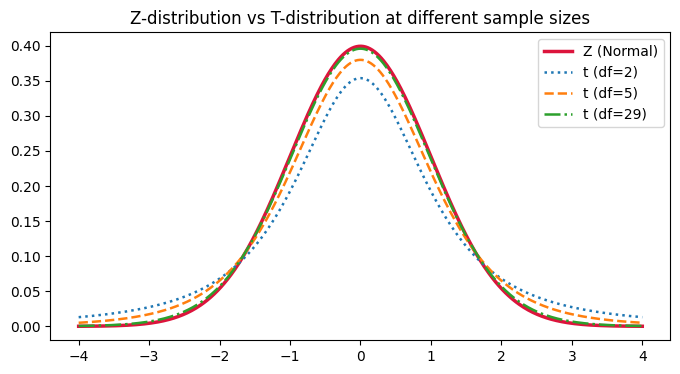

In [2]:
x = np.linspace(-4, 4, 500)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, st.norm.pdf(x), color="crimson", linewidth=2.5, label="Z (Normal)")

for df_, style in [(2, ":"), (5, "--"), (29, "-.")]:
    ax.plot(x, st.t.pdf(x, df_), linestyle=style, linewidth=1.8, label=f"t (df={df_})")

ax.set_title("Z-distribution vs T-distribution at different sample sizes")
ax.legend()
plt.show()

## Same data, both formulas

To make the difference concrete: same sample, computed both ways. In practice you'd only ever use **one** of these (per the flowchart above) — this is just to compare the mechanics side by side.

In [3]:
x_bar = 148     # sample mean
mu = 150        # population mean (claimed)
n = 25          # sample size

sigma = 5       # population std -> used only for Z
S = 5           # sample std     -> used only for T

z_test = (x_bar - mu) / (sigma / np.sqrt(n))
t_test = (x_bar - mu) / (S / np.sqrt(n))

print("z_test:", z_test)
print("t_test:", t_test)
print("df for t:", n - 1)

z_test: -2.0
t_test: -2.0
df for t: 24


**Note:** with the same numbers, $z_{test}$ and $t_{test}$ come out equal — the difference isn't in the statistic's arithmetic, it's in **which critical value / distribution** you compare it against (`st.norm.ppf` vs `st.t.ppf(..., df)`). The t-distribution's critical value is always slightly larger (more conservative) for the same $\alpha$, especially at low `df`.

Next: worked full examples with critical values and decision rules are in **09_Hypothesis_Testing_T-Test.ipynb** and **10_Hypothesis_Testing_T-Test.ipynb**.